In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# DATA

In [2]:
# ---------------------------------------------------------
# Data Import
# ---------------------------------------------------------
natgas_df = pd.read_csv("Nat_Gas.csv")
natgas_df["Dates"] = pd.to_datetime(natgas_df["Dates"])

prices = natgas_df["Prices"].values
dates = natgas_df["Dates"]


print(natgas_df)

        Dates  Prices
0  2020-10-31   10.10
1  2020-11-30   10.30
2  2020-12-31   11.00
3  2021-01-31   10.90
4  2021-02-28   10.90
5  2021-03-31   10.90
6  2021-04-30   10.40
7  2021-05-31    9.84
8  2021-06-30   10.00
9  2021-07-31   10.10
10 2021-08-31   10.30
11 2021-09-30   10.20
12 2021-10-31   10.10
13 2021-11-30   11.20
14 2021-12-31   11.40
15 2022-01-31   11.50
16 2022-02-28   11.80
17 2022-03-31   11.50
18 2022-04-30   10.70
19 2022-05-31   10.70
20 2022-06-30   10.40
21 2022-07-31   10.50
22 2022-08-31   10.40
23 2022-09-30   10.80
24 2022-10-31   11.00
25 2022-11-30   11.60
26 2022-12-31   11.60
27 2023-01-31   12.10
28 2023-02-28   11.70
29 2023-03-31   12.00
30 2023-04-30   11.50
31 2023-05-31   11.20
32 2023-06-30   10.90
33 2023-07-31   11.40
34 2023-08-31   11.10
35 2023-09-30   11.50
36 2023-10-31   11.80
37 2023-11-30   12.20
38 2023-12-31   12.80
39 2024-01-31   12.60
40 2024-02-29   12.40
41 2024-03-31   12.70
42 2024-04-30   12.10
43 2024-05-31   11.40
44 2024-06

C:\Users\Owner\AppData\Local\Temp\ipykernel_10164\3696934390.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  natgas_df["Dates"] = pd.to_datetime(natgas_df["Dates"])


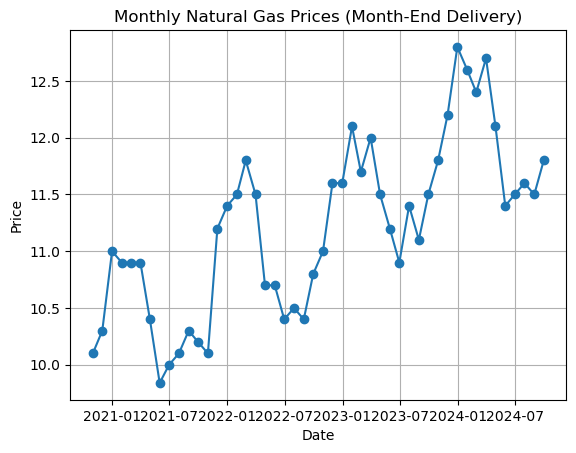

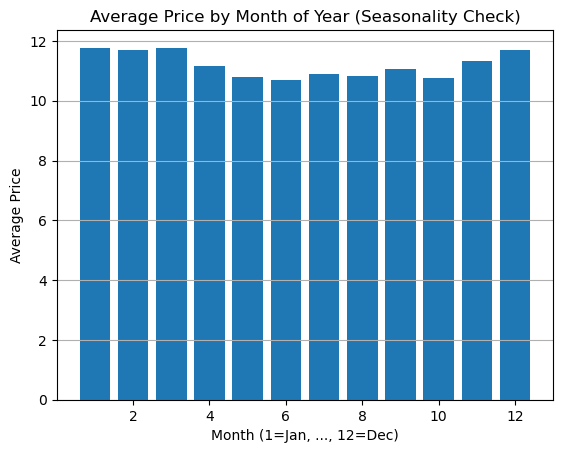

In [3]:
# ---------------------------------------------------------
# Data Visualize
# ---------------------------------------------------------
plt.figure()
plt.plot(natgas_df["Dates"], natgas_df["Prices"], marker="o")
plt.title("Monthly Natural Gas Prices (Month-End Delivery)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# Average price by calendar month
natgas_df["Month"] = natgas_df["Dates"].dt.month
month_avg = natgas_df.groupby("Month")["Prices"].mean()

plt.figure()
plt.bar(month_avg.index, month_avg.values)
plt.title("Average Price by Month of Year (Seasonality Check)")
plt.xlabel("Month (1=Jan, ..., 12=Dec)")
plt.ylabel("Average Price")
plt.grid(axis="y")
plt.show()

# INTERPOLATE

In [ ]:
from data_0 import natgas_df, pd, plt, np


date_int = natgas_df["Dates"].values.astype("datetime64[D]").astype(int)
price_vals = natgas_df["Prices"].values

def interpolate_price(query_date):
    q = pd.to_datetime(query_date)
    q_int = q.to_datetime64().astype("datetime64[D]").astype(int)
    return float(np.interp(q_int, date_int, price_vals))

# Test
print("/")
print("Interpolation check (15/12/2022):",interpolate_price("2022-11-15"))

# EXTRAPOLATE

# PRICING MODEL